In [108]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timezone, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, make_scorer, accuracy_score

churntrain = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_2025-12-21.csv")

# CSV_DIR = r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training"

# latest_csv = max(
#     [os.path.join(CSV_DIR, f) for f in os.listdir(CSV_DIR) if f.endswith(".csv")],
#     key=os.path.getmtime
# )

# churntrain = pd.read_csv(latest_csv)


In [109]:

MODEL_NAME = "XgbChurn"
MODEL_VERSION = "v1.0"
MODEL_CODE = f"{MODEL_NAME}_{MODEL_VERSION}"


In [110]:
id_series = churntrain["spbiid"].copy()

In [111]:
X = churntrain.drop(columns=["spbiid", "churn60d"])
y = churntrain["churn60d"]

In [112]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, id_series, test_size=0.2, random_state=42, stratify=y
)

In [113]:

def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    

In [ ]:
import xgboost as xgb
import time
train_start_time = int(time.time())
# train_start_time = int(time.mktime(time.strptime("2025-12-12", "%Y-%m-%d")))
model_xgb = xgb.XGBClassifier(
    # objective="binary:logistic",
    #     eval_metric="logloss",
    #     n_estimators=300,
    #     max_depth=5,
    #     learning_rate=0.07,
    #     subsample=1,
    #     colsample_bytree=1,
    #     n_jobs=-1,
    #     random_state=42,
    #     reg_lambda = 10, 
    #     reg_alpha = 1, 
    #     min_child_weight = 5, 
    #     gamma = 0

    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=450,
    learning_rate=0.05,
    max_depth=5,              
    min_child_weight=5,       
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,                
    reg_alpha=1,
    reg_lambda=10,
    n_jobs=-1,
    random_state=42
)
model_xgb.fit( X_train, y_train)

train_end_time = int(time.time())
# train_end_time = int(time.mktime(time.strptime("2025-12-12", "%Y-%m-%d")))
y_pred_xgb = model_xgb.predict(X_test)
y_train_xgb = model_xgb.predict(X_train)
evaluate_model("XGB", y_test, y_pred_xgb)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

conf_mat = confusion_matrix(y_test, y_pred_xgb)
class_report = classification_report(
    y_test, y_pred_xgb, output_dict=True
)




===== XGB =====
Accuracy : 0.922
Precision: 0.9271
Recall   : 0.9519
F1 Score : 0.9393

Confusion Matrix:
[[ 94  14]
 [  9 178]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       108
           1       0.93      0.95      0.94       187

    accuracy                           0.92       295
   macro avg       0.92      0.91      0.92       295
weighted avg       0.92      0.92      0.92       295



## Feature


Top đặc trưng quan trọng nhất:
               Feature  Importance
1           copoorder    0.207828
18    trantotalearned    0.174401
23      delaybinnoise    0.127408
0      totalcompleted    0.113051
3      ordercycletime    0.062257
21     remainingpoint    0.045984
12      call60damount    0.034455
19   eventtotalearned    0.034029
17  beflaodahashmount    0.025061
13     calllaodamount    0.021870
9    requestdocamount    0.017995
14       aftlastduavg    0.017682
10     responseamount    0.016196
7       uplevelamount    0.015825
15        bef60dduavg    0.015075
6          curpercent    0.013407
5        startpercent    0.012164
16    befpnhashamount    0.010491
4             copoavg    0.010453
2         incopoorder    0.010102
22             spccid    0.008486
8       uplevelstatus    0.005779
11       resultamount    0.000000
20    corpominuspoint    0.000000


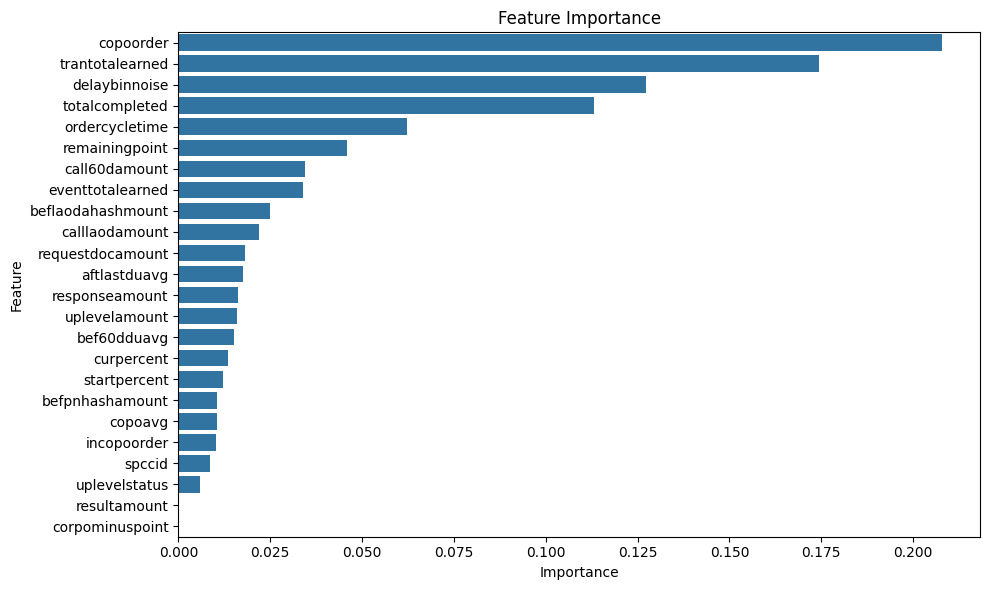

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xgb.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop đặc trưng quan trọng nhất:\n", feat_imp)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Lưu model

In [ ]:
import joblib

# tự động lấy ngày hiện tại
date_str = datetime.now().strftime("%Y%m%d")

path = r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\models"
os.makedirs(path, exist_ok=True)
# file_name = f"{MODEL_CODE}.pkl"
# file_path = os.path.join(path, f"{MODEL_CODE}_20251221.pkl")

file_path = os.path.join(path, f"{MODEL_CODE}_{date_str}.pkl")

joblib.dump(
    {
        "model": model_xgb,
        "train_date": train_end_time,
        # "model_version": "XgbChurn_v1.0"
        "model_version": MODEL_CODE
    },
    # "XgbChurn_v1.0_251221.pkl"
    file_path
)

['D:\\CongTyObiuty\\2. DuAn\\3. ThayCong\\2. Obiuty\\2. AiData\\Database\\training\\models\\XgbChurn_v1.0_20251221.pkl']

In [118]:
from sklearn.metrics import classification_report

class_report = classification_report(
    y_test,
    y_pred_xgb,
    output_dict=True
)
def round_metric_dict(d, n=2):
    return {
        k: (round(v, n) if isinstance(v, float) else v)
        for k, v in d.items()
    }

class_report_rounded = {
    k: round_metric_dict(v, 2)
    for k, v in class_report.items()
    if isinstance(v, dict)
}
chtl_result_dict = {
    "accuracy": round(class_report["accuracy"], 2),
    "macro avg": class_report_rounded["macro avg"],
    "weighted avg": class_report_rounded["weighted avg"]
}


In [119]:
label_results = {
    label: {
        "precision": class_report_rounded[label]["precision"],
        "recall": class_report_rounded[label]["recall"],
        "f1_score": class_report_rounded[label]["f1-score"],
        "support": int(class_report_rounded[label]["support"])
    }
    for label in ["0", "1"]
}


In [120]:
import json

output_path = r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrainlog1.csv"

if os.path.exists(output_path):
    df_old = pd.read_csv(output_path)
    next_id = df_old["chtl_id"].max() + 1
    write_header = False
else:
    next_id = 1
    write_header = True

df_log = pd.DataFrame([{
    "chtl_id": next_id,
    "chtl_code": MODEL_CODE,
    "chtl_model": MODEL_NAME,
    "chtl_version": MODEL_VERSION,
    "chtl_modeltraningtime": train_end_time,
    "chtl_starttime": train_start_time,
    "chtl_endtime": train_end_time,
    "chtl_trainrecordamount": len(X_train),
    "chtl_testrecordamount": len(X_test),

    # "chtl_accuracy": round(class_report["accuracy"], 4),
    # "chtl_precision": round(class_report["weighted avg"]["precision"], 4),
    # "chtl_recall": round(class_report["weighted avg"]["recall"], 4),
    # "chtl_f1score": round(class_report["weighted avg"]["f1-score"], 4),

    "chtl_accuracy": round(accuracy, 4),
    "chtl_precision": round(precision, 4),
    "chtl_recall": round(recall, 4),
    "chtl_f1score": round(f1, 4),

    "chtl_classamount": len(class_report_rounded) - 2 ,  # bỏ macro, weighted
    "chtl_classresult": json.dumps(label_results),

    "chtl_result": json.dumps(chtl_result_dict)
}])

In [121]:
write_header = not os.path.exists(output_path)

df_log.to_csv(
    output_path,
    mode="a",
    header=write_header,
    index=False,
    encoding="utf-8-sig"
)
